# Semana 2: Análisis exploratorio de datos

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline 

In [4]:
df = pd.read_csv("dataset/titanic.csv")
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN


In [5]:
df.dtypes

pclass         int64
survived       int64
name          object
sex           object
age          float64
sibsp          int64
parch          int64
ticket        object
fare         float64
cabin         object
embarked      object
boat          object
body         float64
home.dest     object
dtype: object

In [6]:
df = df.drop(["survived","name","ticket","cabin","boat","body","home.dest"],axis=1)
df

,pclass,sex,age,sibsp,parch,fare,embarked
0,1,female,29.0000,0,0,211.3375,S
1,1,male,0.9167,1,2,151.5500,S
2,1,female,2.0000,1,2,151.5500,S
3,1,male,30.0000,1,2,151.5500,S
4,1,female,25.0000,1,2,151.5500,S
...,...,...,...,...,...,...,...
1304,3,female,14.5000,1,0,14.4542,C
1305,3,female,NaN,1,0,14.4542,C
1306,3,male,26.5000,0,0,7.2250,C
1307,3,male,27.0000,0,0,7.2250,C


In [7]:
# Imputación para la variable age
avg_age = df['age'].median()
avg_age = round(avg_age,2)      
print("El promedio de la variable age es", avg_age)
df["age"].replace(np.nan, avg_age, inplace=True)

El promedio de la variable age es 28.0


/var/folders/c7/p02yvsh9697_g6yclqsn8p440000gn/T/ipykernel_31226/522260881.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["age"].replace(np.nan, avg_age, inplace=True)


In [8]:
# Imputación para la variable embarked
mode = df['embarked'].value_counts().idxmax()
print("La moda de la variable embarked es", mode)
df["embarked"].replace(np.nan, mode, inplace=True)

La moda de la variable embarked es S


/var/folders/c7/p02yvsh9697_g6yclqsn8p440000gn/T/ipykernel_31226/3145363035.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["embarked"].replace(np.nan, mode, inplace=True)


In [9]:
df.isnull().sum()

pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        1
embarked    0
dtype: int64

In [10]:
df.isnull().sum()

pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        1
embarked    0
dtype: int64

In [11]:
# Automatizondo las conversiones de variables
variables = ["pclass"]
for i in variables:
    df[i] = df[i].astype("object")

df.dtypes

pclass       object
sex          object
age         float64
sibsp         int64
parch         int64
fare        float64
embarked     object
dtype: object

In [12]:
df['pclass'].replace([1,2,3],['1st','2nd','3rd'],inplace=True)
#df['survived'].replace([0,1],['no','yes'],inplace=True)
df

/var/folders/c7/p02yvsh9697_g6yclqsn8p440000gn/T/ipykernel_31226/1869358320.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['pclass'].replace([1,2,3],['1st','2nd','3rd'],inplace=True)


,pclass,sex,age,sibsp,parch,fare,embarked
0,1st,female,29.0000,0,0,211.3375,S
1,1st,male,0.9167,1,2,151.5500,S
2,1st,female,2.0000,1,2,151.5500,S
3,1st,male,30.0000,1,2,151.5500,S
4,1st,female,25.0000,1,2,151.5500,S
...,...,...,...,...,...,...,...
1304,3rd,female,14.5000,1,0,14.4542,C
1305,3rd,female,28.0000,1,0,14.4542,C
1306,3rd,male,26.5000,0,0,7.2250,C
1307,3rd,male,27.0000,0,0,7.2250,C


In [13]:
df.to_csv("titanic_sin_nan.csv")

### Pregunta 1

In [14]:
df = pd.read_csv("titanic_sin_nan.csv")
df = df.drop(["Unnamed: 0"],axis=1)
df

,pclass,sex,age,sibsp,parch,fare,embarked
0,1st,female,29.0000,0,0,211.3375,S
1,1st,male,0.9167,1,2,151.5500,S
2,1st,female,2.0000,1,2,151.5500,S
3,1st,male,30.0000,1,2,151.5500,S
4,1st,female,25.0000,1,2,151.5500,S
...,...,...,...,...,...,...,...
1304,3rd,female,14.5000,1,0,14.4542,C
1305,3rd,female,28.0000,1,0,14.4542,C
1306,3rd,male,26.5000,0,0,7.2250,C
1307,3rd,male,27.0000,0,0,7.2250,C


In [15]:
df.dtypes

pclass       object
sex          object
age         float64
sibsp         int64
parch         int64
fare        float64
embarked     object
dtype: object

In [16]:
df.isnull().sum()

pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        1
embarked    0
dtype: int64

In [17]:
df.dropna(axis=0, inplace=True)

In [18]:
df.isnull().sum()

pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

In [19]:
v_numericas = df.select_dtypes(["float64","int64"])
v_numericas = list(v_numericas.columns)
v_numericas

['age', 'sibsp', 'parch', 'fare']

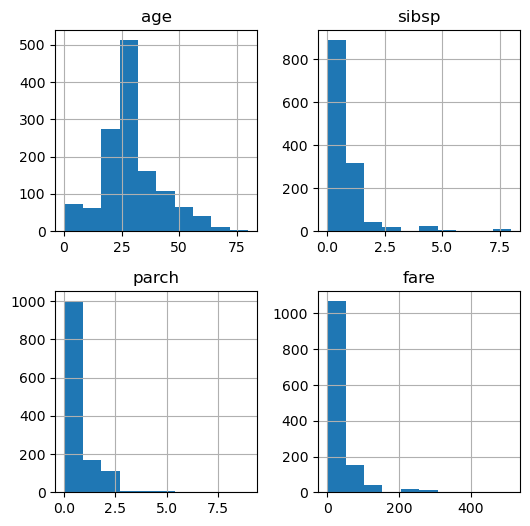

In [20]:
df[v_numericas].hist(layout=(2,2),
                     sharex=False,sharey=False,figsize=(6,6))
plt.show()

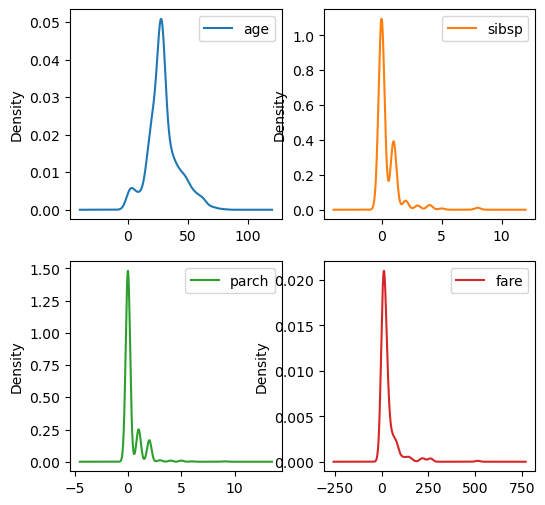

In [21]:
df[v_numericas].plot(kind='density',subplots=True,layout=(2,2),
                     sharex=False,sharey=False,figsize=(6,6))
plt.show()

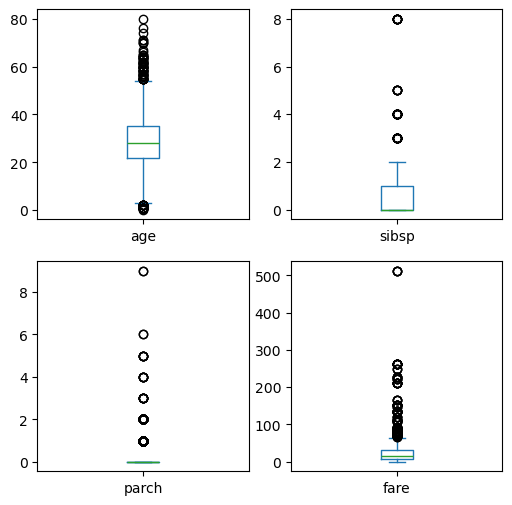

In [22]:
df[v_numericas].plot(kind='box',subplots=True,layout=(2,2),
                     sharex=False,sharey=False,figsize=(6,6))
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/pandas/plotting/_matplotlib/misc.py:96: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


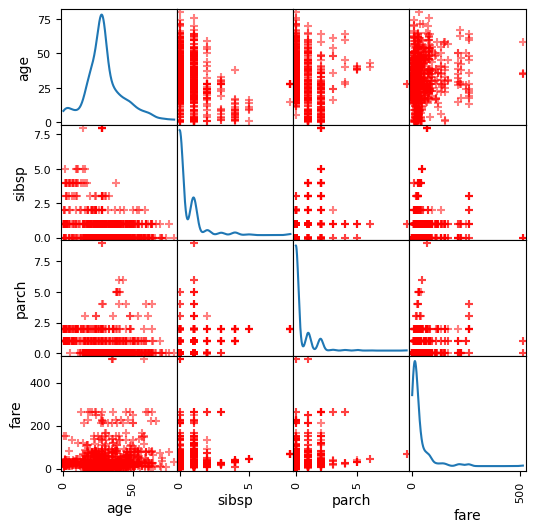

In [23]:
from pandas.plotting import scatter_matrix
scatter_matrix(df[v_numericas],figsize=(6,6),color='red',
               diagonal="kde",marker='+')
plt.show()

In [24]:
df[v_numericas].corr()

,age,sibsp,parch,fare
age,1.000000,-0.189527,-0.125320,0.179255
sibsp,-0.189527,1.000000,0.373485,0.160238
parch,-0.125320,0.373485,1.000000,0.221539
fare,0.179255,0.160238,0.221539,1.000000


In [25]:
def heatmap_corr(lista):
    correlaciones = df[lista].corr(method='pearson')
    correlaciones1 = correlaciones.to_numpy()
    fig, ax = plt.subplots(figsize=(8,8))
    cax = ax.imshow(correlaciones,cmap="Blues",vmin=-1,vmax=1)
    fig.colorbar(cax)
    ax.set_xticks(np.arange(len(lista)),labels=lista)
    ax.set_yticks(np.arange(len(lista)),labels=lista)
    for i in range(len(lista)):
        for j in range(len(lista)):
            text = ax.text(j,i,round(correlaciones1[i,j],2),
                       ha="center",va="center",color="w")
    plt.show()

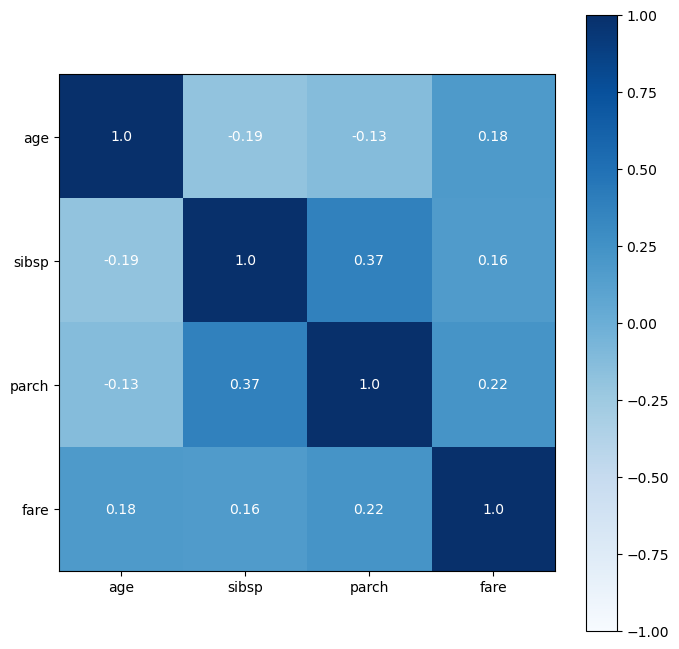

In [26]:
heatmap_corr(v_numericas)

### Pregunta 2

In [27]:
sns.regplot(x="age", y="fare", data=df)

<Axes: xlabel='age', ylabel='fare'>

In [28]:
sns.regplot(x="sibsp", y="fare", data=df)

<Axes: xlabel='sibsp', ylabel='fare'>

In [29]:
sns.regplot(x="parch", y="fare", data=df)

<Axes: xlabel='parch', ylabel='fare'>

In [30]:
sns.boxplot(x="pclass", y="fare", data=df)

<Axes: xlabel='parch', ylabel='fare'>

In [31]:
sns.boxplot(x="sex", y="fare", data=df)

<Axes: xlabel='parch', ylabel='fare'>

In [32]:
sns.boxplot(x="embarked", y="fare", data=df)

<Axes: xlabel='parch', ylabel='fare'>

In [33]:
df_gptest1 = df[['pclass','sex','fare']]
grouped_test1 = df_gptest1.groupby(['pclass','sex'],as_index=False).mean()
grouped_test1

,pclass,sex,fare
0,1st,female,109.412385
1,1st,male,69.888385
2,2nd,female,23.234827
3,2nd,male,19.904946
4,3rd,female,15.324250
5,3rd,male,12.415462


In [34]:
grouped_pivot1 = grouped_test1.pivot(index='pclass',columns='sex')
grouped_pivot1 = grouped_pivot1.fillna(0)
grouped_pivot1 = round(grouped_pivot1, 2)
grouped_pivot1

fare       
sex     female   male
pclass               
1st     109.41  69.89
2nd      23.23  19.90
3rd      15.32  12.42

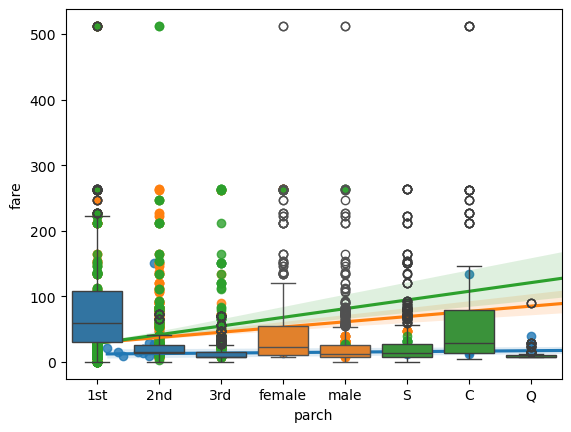

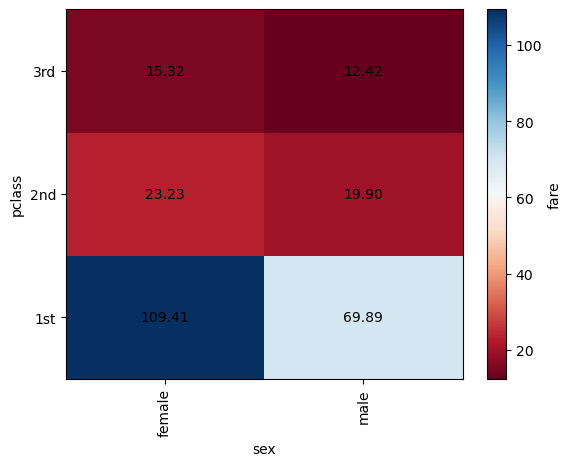

In [35]:
fig, ax = plt.subplots()
im = ax.pcolor(grouped_pivot1, cmap='RdBu')

row_labels = grouped_pivot1.columns.get_level_values(1)
col_labels = grouped_pivot1.index

ax.set_xticks(np.arange(grouped_pivot1.shape[1]) + 0.5, minor=False)
ax.set_yticks(np.arange(grouped_pivot1.shape[0]) + 0.5, minor=False)
ax.set_xticklabels(row_labels, minor=False)
ax.set_yticklabels(col_labels, minor=False)

ax.set_ylabel("pclass")
ax.set_xlabel("sex")
plt.xticks(rotation=90)
fig.colorbar(im, label="fare")

for y in range(grouped_pivot1.shape[0]):
    for x in range(grouped_pivot1.shape[1]):
        plt.text(x + 0.5, y + 0.5, '%.2f' % grouped_pivot1.iloc[y, x],
                 horizontalalignment='center',
                 verticalalignment='center')

plt.show()

In [36]:
df_gptest2 = df[['pclass','embarked','fare']]
grouped_test2 = df_gptest2.groupby(['pclass','embarked'],as_index=False).mean()
grouped_test2

,pclass,embarked,fare
0,1st,C,106.845330
1,1st,Q,90.000000
2,1st,S,72.235825
3,2nd,C,23.300593
4,2nd,Q,11.735114
5,2nd,S,21.206921
6,3rd,C,11.021624
7,3rd,Q,10.390820
8,3rd,S,14.435422


In [37]:
grouped_pivot2 = grouped_test2.pivot(index='pclass',columns='embarked')
grouped_pivot2 = grouped_pivot2.fillna(0)
grouped_pivot2 = round(grouped_pivot2, 2)
grouped_pivot2

fare              
embarked       C      Q      S
pclass                        
1st       106.85  90.00  72.24
2nd        23.30  11.74  21.21
3rd        11.02  10.39  14.44

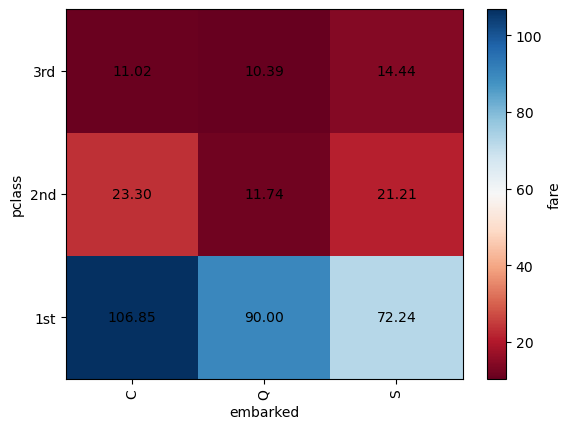

In [38]:
fig, ax = plt.subplots()
im = ax.pcolor(grouped_pivot2, cmap='RdBu')

row_labels = grouped_pivot2.columns.get_level_values(1)
col_labels = grouped_pivot2.index

ax.set_xticks(np.arange(grouped_pivot2.shape[1]) + 0.5, minor=False)
ax.set_yticks(np.arange(grouped_pivot2.shape[0]) + 0.5, minor=False)
ax.set_xticklabels(row_labels, minor=False)
ax.set_yticklabels(col_labels, minor=False)

ax.set_ylabel("pclass")
ax.set_xlabel("embarked")
plt.xticks(rotation=90)
fig.colorbar(im, label="fare")

for y in range(grouped_pivot2.shape[0]):
    for x in range(grouped_pivot2.shape[1]):
        plt.text(x + 0.5, y + 0.5, '%.2f' % grouped_pivot2.iloc[y, x],
                 horizontalalignment='center',
                 verticalalignment='center')

plt.show()

In [39]:
df_gptest3 = df[['sex','embarked','fare']]
grouped_test3 = df_gptest3.groupby(['sex','embarked'],as_index=False).mean()
grouped_test3

,sex,embarked,fare
0,female,C,81.128540
1,female,Q,12.550837
2,female,S,39.616853
3,male,C,48.810619
4,male,Q,12.273941
5,male,S,21.841878


In [40]:
grouped_pivot3 = grouped_test3.pivot(index='sex',columns='embarked')
grouped_pivot3 = grouped_pivot3.fillna(0)
grouped_pivot3 = round(grouped_pivot3, 2)
grouped_pivot3

fare              
embarked      C      Q      S
sex                          
female    81.13  12.55  39.62
male      48.81  12.27  21.84

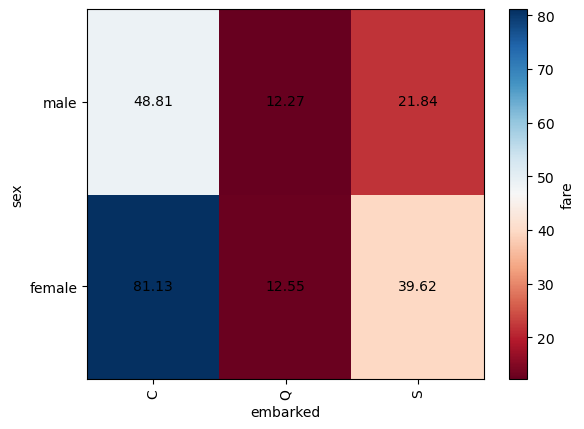

In [41]:
fig, ax = plt.subplots()
im = ax.pcolor(grouped_pivot3, cmap='RdBu')

row_labels = grouped_pivot3.columns.get_level_values(1)
col_labels = grouped_pivot3.index

ax.set_xticks(np.arange(grouped_pivot3.shape[1]) + 0.5, minor=False)
ax.set_yticks(np.arange(grouped_pivot3.shape[0]) + 0.5, minor=False)
ax.set_xticklabels(row_labels, minor=False)
ax.set_yticklabels(col_labels, minor=False)

ax.set_ylabel("sex")
ax.set_xlabel("embarked")
plt.xticks(rotation=90)
fig.colorbar(im, label="fare")

for y in range(grouped_pivot3.shape[0]):
    for x in range(grouped_pivot3.shape[1]):
        plt.text(x + 0.5, y + 0.5, '%.2f' % grouped_pivot3.iloc[y, x],
                 horizontalalignment='center',
                 verticalalignment='center')

plt.show()

In [42]:
df[v_numericas].describe(percentiles=[0.2, 0.8])

,age,sibsp,parch,fare
count,1308.000000,1308.000000,1308.000000,1308.000000
mean,29.479485,0.499235,0.385321,33.295479
std,12.881658,1.041965,0.865826,51.758668
min,0.166700,0.000000,0.000000,0.000000
20%,21.000000,0.000000,0.000000,7.854200
50%,28.000000,0.000000,0.000000,14.454200
80%,39.000000,1.000000,1.000000,41.579200
max,80.000000,8.000000,9.000000,512.329200


In [43]:
df.describe(include=['object'])

,pclass,sex,embarked
count,1308,1308,1308
unique,3,2,3
top,3rd,male,S
freq,708,842,915


### Pregunta 3

In [44]:
pearson_coef, p_value = stats.pearsonr(df['age'], df['fare'])
print("El coeficiente de correlación de Pearson es", round(pearson_coef,3),
      " con un p-valor de ", p_value)

El coeficiente de correlación de Pearson es 0.179  con un p-valor de  6.587630769461266e-11


In [45]:
pearson_coef, p_value = stats.pearsonr(df['sibsp'], df['fare'])
print("El coeficiente de correlación de Pearson es", round(pearson_coef,3),
      " con un p-valor de ", p_value)

El coeficiente de correlación de Pearson es 0.16  con un p-valor de  5.630627277847121e-09


In [46]:
pearson_coef, p_value = stats.pearsonr(df['parch'], df['fare'])
print("El coeficiente de correlación de Pearson es", round(pearson_coef,3),
      " con un p-valor de ", p_value)

El coeficiente de correlación de Pearson es 0.222  con un p-valor de  5.2532800906682e-16


### Pregunta 4

In [47]:
df["pclass"].unique()

array(['1st', '2nd', '3rd'], dtype=object)

In [48]:
F_val, p_value = stats.f_oneway(df[df["pclass"] == "1st"]["fare"], 
                                df[df["pclass"] == "2nd"]["fare"], 
                                df[df["pclass"] == "3rd"]["fare"])  
 
print("Resultados del ANOVA: F=", F_val,", p-valor =", p_value) 

Resultados del ANOVA: F= 372.7418288117318 , p-valor = 8.904613790086322e-129


In [49]:
df["sex"].unique()

array(['female', 'male'], dtype=object)

In [50]:
F_val, p_value = stats.f_oneway(df[df["sex"] == "female"]["fare"], 
                                df[df["sex"] == "male"]["fare"])  
 
print("Resultados del ANOVA: F=", F_val,", p-valor =", p_value) 

Resultados del ANOVA: F= 46.55322698539302 , p-valor = 1.3605668336088996e-11


In [51]:
df["embarked"].unique()

array(['S', 'C', 'Q'], dtype=object)

In [52]:
F_val, p_value = stats.f_oneway(df[df["embarked"] == "S"]["fare"], 
                                df[df["embarked"] == "C"]["fare"], 
                                df[df["embarked"] == "Q"]["fare"])  
 
print("Resultados del ANOVA: F=", F_val,", p-valor =", p_value) 

Resultados del ANOVA: F= 63.77245040944802 , p-valor = 3.760367014778617e-27
